# PSAT Package Week 3
시계열자료분석팀 2020311350 강철석

# Chapter1 : Graph Data Analysis

## 문제1.
이번 챕터에서는 scipy,networkx가 필수적으로 사용됩니다. 패키지를 설치해주세요.

## 문제2. 
이번 분석에서는 추천시스템에서 매우 유명한 오픈데이터 중 하나인 Anime Recommendations Database를 사용합니다. 
data 폴더 안의 anime.csv rating.csv를 각각 anime_df,rating_df로 불러온 후 간단하게 확인해주세요.

In [2]:
import pandas as pd
anime_df = pd.read_csv("data/anime.csv")
anime_df.drop(columns = ["Unnamed: 0"], inplace = True) 
rating_df = pd.read_csv("data/rating.csv")

In [3]:
display(anime_df.info())
display(rating_df.info())
display(anime_df.head())
display(rating_df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11052 entries, 0 to 11051
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  11052 non-null  int64  
 1   name      11052 non-null  object 
 2   genre     11052 non-null  object 
 3   type      11032 non-null  object 
 4   episodes  11052 non-null  object 
 5   rating    10847 non-null  float64
 6   members   11052 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 604.5+ KB


None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7813737 entries, 0 to 7813736
Data columns (total 3 columns):
 #   Column    Dtype
---  ------    -----
 0   user_id   int64
 1   anime_id  int64
 2   rating    int64
dtypes: int64(3)
memory usage: 178.8 MB


None

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


,user_id,anime_id,rating
0,1,20,-1
1,1,24,-1
2,1,79,-1
3,1,226,-1
4,1,241,-1


## 문제 3. 
이번 분석에서는 평가자 수가 상위 10%에 해당하는 작품들만을 사용합니다. 

member 변수가 상위 10%인 경우만을 골라 결측치가 있는 경우를 제거한 후, anime_top10_df 로 저장해주세요.

In [4]:
# Filter top 10 percent members in anime
q_90 = anime_df["members"].quantile(0.9)
print(q_90)

anime_top10_df = anime_df[anime_df["members"] > q_90]
display(anime_top10_df.isna().sum())
anime_top10_df.dropna(inplace = True)
display(anime_top10_df.isna().sum())

display(anime_top10_df.head())
display(anime_top10_df.info())

51309.19999999995


anime_id    0
name        0
genre       0
type        1
episodes    0
rating      6
members     0
dtype: int64

C:\Users\82102\AppData\Local\Temp\ipykernel_3396\2287280007.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  anime_top10_df.dropna(inplace = True)


anime_id    0
name        0
genre       0
type        0
episodes    0
rating      0
members     0
dtype: int64

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


<class 'pandas.core.frame.DataFrame'>
Index: 1100 entries, 0 to 8003
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  1100 non-null   int64  
 1   name      1100 non-null   object 
 2   genre     1100 non-null   object 
 3   type      1100 non-null   object 
 4   episodes  1100 non-null   object 
 5   rating    1100 non-null   float64
 6   members   1100 non-null   int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 68.8+ KB


None

## 문제4. 
genre 변수에는 각 작품이 해당하는 장르가 여러개 적혀있습니다.

genre에 대한 빈도수를 아래와 같이 시각화해주세요.

- (조건) xticks의 rotation을 45도로 설정해주세요
- (HINT) split()과 explode()함수를 활용하시면 쉽게 1개 단위의 Series를 만들 수 있습니다

C:\Users\82102\AppData\Local\Temp\ipykernel_3396\3611779268.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  anime_top10_df["genre_split"] = anime_top10_df["genre"].apply(lambda x: x.split(","))
C:\Users\82102\AppData\Local\Temp\ipykernel_3396\3611779268.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  anime_top10_df["genre_split"] = anime_top10_df["genre_split"].apply(lambda x: [i.strip() for i in x])


,anime_id,name,genre,type,episodes,rating,members,genre_split
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630,Drama
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630,Romance
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630,School
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630,Supernatural
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665,Action


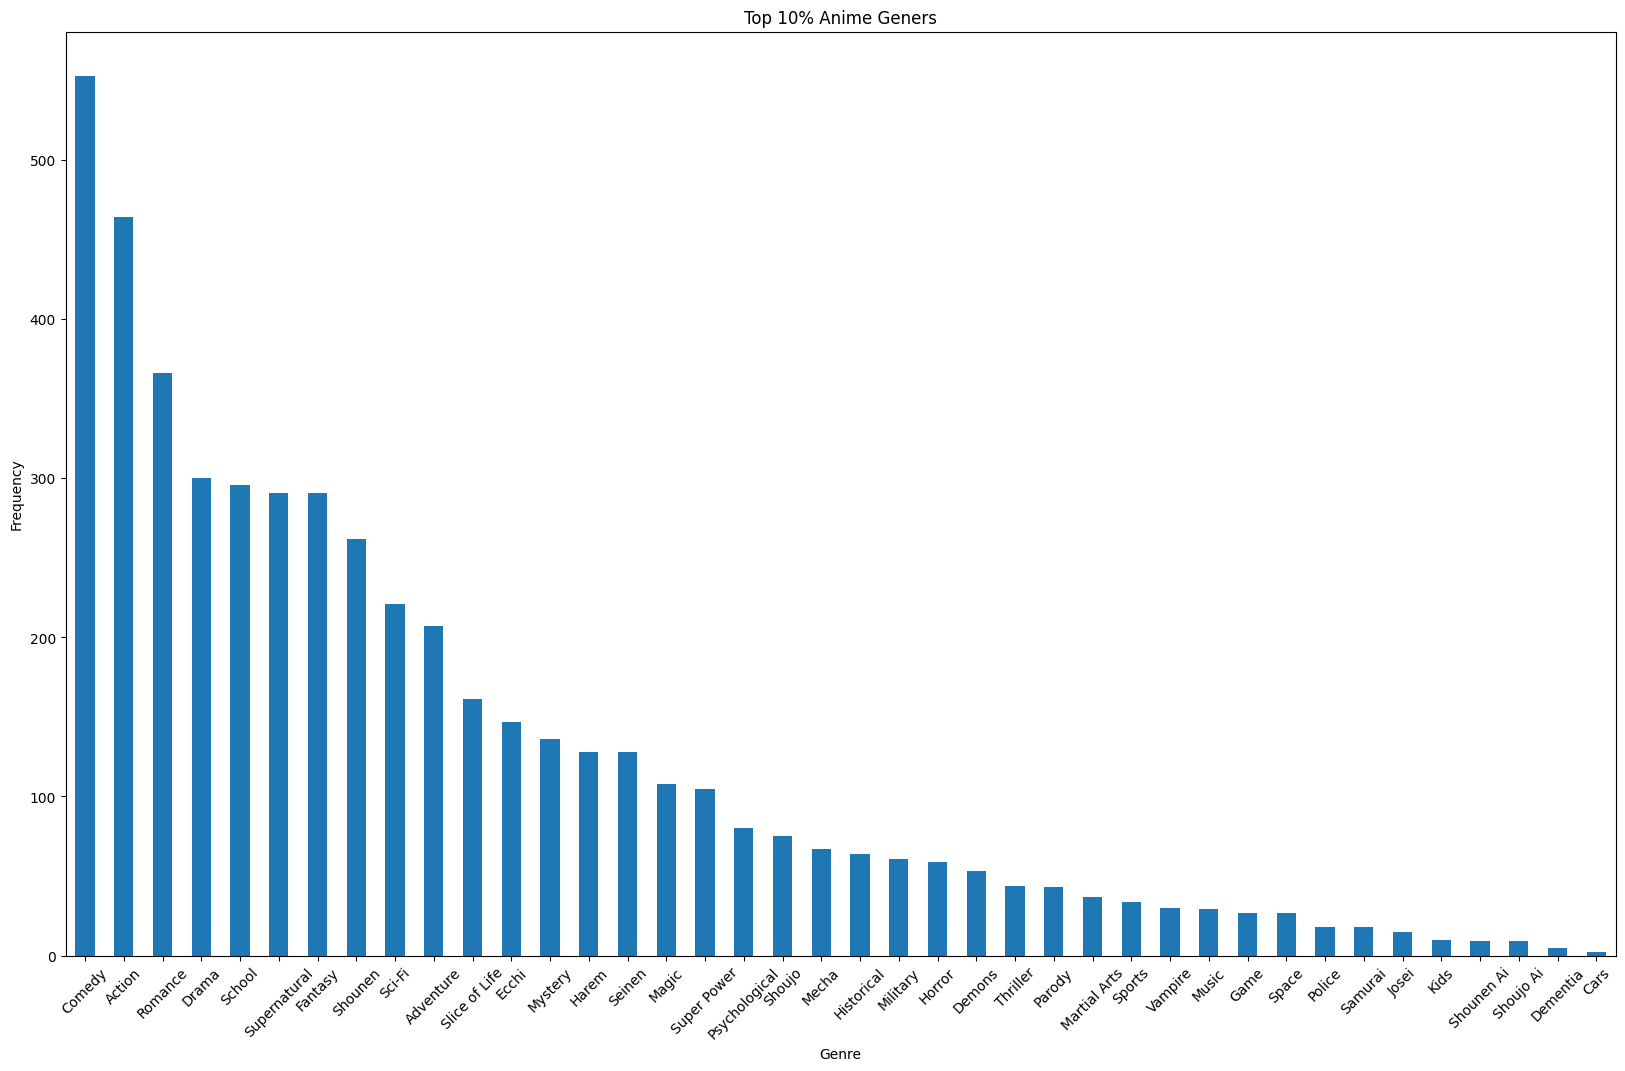

In [5]:
import matplotlib.pyplot as plt

# apply split genre column
anime_top10_df["genre_split"] = anime_top10_df["genre"].apply(lambda x: x.split(","))

# trim the genre_split column
anime_top10_df["genre_split"] = anime_top10_df["genre_split"].apply(lambda x: [i.strip() for i in x])

# use explode to split the genre column
anime_genre_top10_df = anime_top10_df.explode("genre_split")
display(anime_genre_top10_df.head())



plt.figure(figsize = (20, 12))

anime_genre_top10_df["genre_split"].value_counts().plot(kind = "bar")
plt.title("Top 10% Anime Geners")
plt.xlabel("Genre")
plt.xticks(rotation = 45)
plt.ylabel("Frequency")
plt.show()

## 문제5.
rating_df 중에서 user_id가 1000 미만인 경우만 사용할 예정입니다. 필터링을 진행해주세요.

In [6]:
rating_df = rating_df[rating_df["user_id"] < 1000]
display(rating_df.head())

print(rating_df.shape)

,user_id,anime_id,rating
0,1,20,-1
1,1,24,-1
2,1,79,-1
3,1,226,-1
4,1,241,-1


(96438, 3)


## 문제6.
rating_df의 user_id 별로 anime_id가 anime_top10_df의 anime_id에 존재하는 경우만 골라 필터 링하고, 

user_id 별로 상위 3개의 rating 작품만을 남겨 rating_df_selected에 저장해주세요.

- (조건) 시청은 하였으나 rating을 표기하지 않은 경우 -1로 나타나있습니다. 해당 경우는 함께 제거해주세요.
- 따라서 3개보다 적은 행을 가진 user_id가 등장할 수 있습니다


In [7]:
def filter_user_id(rating_df, anime_top10_df = None, leave_top3 = True):
    # anime_id filtering
    # user_id_list = rating_df["user_id"].unique()
    rating_filtered = rating_df.copy()

    # filter rating with anime_id in top10
    anime_id_list = anime_top10_df["anime_id"].unique()
    rating_filtered = rating_filtered[rating_filtered["anime_id"].isin(anime_id_list)]

    # -1: minus one means seen but not rated
    rating_mo_filtered = rating_filtered[rating_filtered["rating"] != -1]
    user_id_filtered = rating_mo_filtered["user_id"].unique()
    
    # Leave only top 3 rating rows for each user id
    if leave_top3:
        rating_df_selected = pd.DataFrame()
        for user_id in user_id_filtered:
            rating_df_selected = pd.concat([rating_df_selected, rating_mo_filtered[rating_mo_filtered["user_id"] == user_id].nlargest(3, "rating")])
    else:
        rating_df_selected = rating_mo_filtered

    return rating_df_selected

In [8]:
rating_df_selected = filter_user_id(rating_df, anime_top10_df)
print(rating_df_selected.shape)

(2671, 3)


In [9]:
display(rating_df_selected.head())

,user_id,anime_id,rating
47,1,8074,10
81,1,11617,10
83,1,11757,10
153,2,11771,10
159,3,199,10


In [ ]:
rating_df_selected.groupby("user_id")["rating"].count()

# 문제7.
rating 분포가 정규분포의 양상을 따르는지 판단하고 싶습니다. 

그러나, 지나치게 엄밀한 검정은 오히려 해가 될 수 있기 때문에 Skewness-Kurtosis Normality 판단법을 활용하고자 합니다.
해당 방법에 대해 설명해주세요.
- (HINT) Jarque-Bera test와 원리는 같지만 좀 더 간단하고 유연한 판단 방법입니다. 
- 따라서 엄밀하지 않게 정규성의 양상을 띄는지만 확인하기 위해 자주 사용됩니다. 
- 본 판단법은 Hairetal.(2010) and Bryne (2010)의 방법을 기준으로 하므로 해당 기준에 대해 설명해주시면 됩니다

> -2 < Skewness < 2, -7 < Kurtosis < 7 인 경우 정규분포를 따른다고 간주한다.

# 문제8.
anime_top10_df의 rating의 평균과 표준편차를 구하고, 다음과 같이 Density 시각화를 진행해주세요

- (조건1) 해당 평균과 표준편차의 정규분포 곡선을 그래프에 나타내주세요. 이때, 색은 검은색,linewidth는 2 로 설정해주세요.
- (조건2) grid를 표시해주고,title에 mu,std로 평균과 표준편차를 나타내주세요.

N(7.71, 0.6)


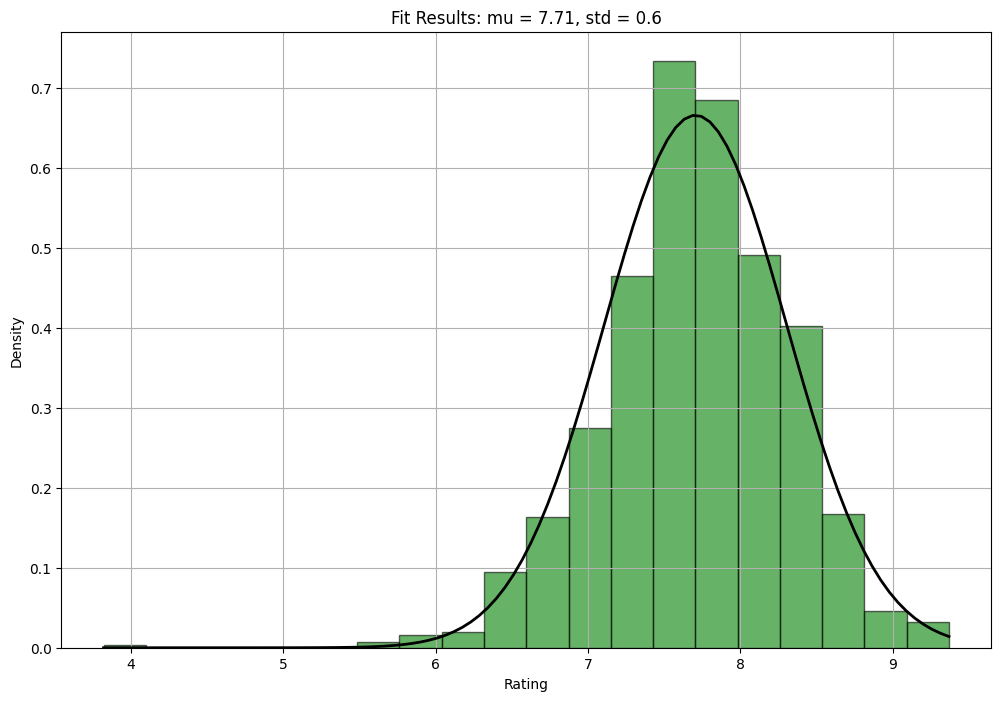

In [116]:
import numpy as np
import scipy.stats as stats

# mean and standard deviation of rating
mu = anime_top10_df["rating"].mean()
sigma = anime_top10_df["rating"].std()
print(f"N({round(mu, 2)}, {round(sigma, 2)})")


# plot normal distribution with mean and standard deviation
normal_value = np.linspace(anime_top10_df["rating"].min(), anime_top10_df["rating"].max(), 100)

plt.figure(figsize = (12, 8))
plt.hist(anime_top10_df["rating"], bins = 20, color = "green", density = True, 
         zorder = 1, alpha = 0.6, edgecolor = "black")
plt.plot(normal_value, stats.norm.pdf(normal_value, mu, sigma), color = "black", linewidth = 2)

plt.title(f"Fit Results: mu = {round(mu, 2)}, std = {round(sigma, 2)}")
plt.xlabel("Rating")
plt.ylabel("Density")
plt.grid(zorder = 3)
plt.show()

# 문제9. 
anime_top10_df의 rating의 skewness와 kurtosis를 구한 후, 정규분포로 가정해도 무방한지 의견을 작성해주세요.

Skewness의 절대값이 2보다 작고, Kurtosis의 절대값이 7보다 작으므로 정규분포로 가정해도 무방하다

In [117]:
# get anime_top10_df's skewness and kurtosis
skewness = anime_top10_df["rating"].skew()
kurtosis = anime_top10_df["rating"].kurt()
print(f"Skewness: {skewness}, Kurtosis: {kurtosis}")

Skewness: -0.4809717238597765, Kurtosis: 1.6213900764428586


## 문제10.
지금부터 그래프 데이터에 대한 분석을 진행하겠습니다. 먼저, 그래프 데이터가 무엇인지 자세히 설명해주세요.
- (조건) Node,Edge,Weight에 대한 정의가 포함되어야 합니다.


- Node: 정점, 각 객체...?
- Edge: 간선, 두 노드 사이 간선이 존재할 경우 두 노드가 연결되어있음을 뜻한다. 
- Weight: 가중치, 간선에 부여되는 가중치로 두 정점사이의 거리, 연과성 등 다양하게 정의될 수 있다.

## 문제11.
networkx 패키지를 불러온 후, 초기 그래프를 생성해주세요.
- (HINT) G = nx.Graph()를 통해 초기 그래프를 G로 생성할 수 있습니다.

In [13]:
import networkx as nx
G = nx.Graph()

## 문제12.
그래프에 노드를 먼저 추가하겠습니다.

rating_df_selected에 존재하는 user_id,anime_id를 노드로 추가해주세요.
- (조건) user_nodes는 user_{숫자}로 설정해주세요. 데이터프레임 자체에서 바꾸어도 무방합니다

In [14]:
rating_df_selected["user_id_str"] = rating_df_selected["user_id"].astype(str)
rating_df_selected["user_id_str"] = "user_" + rating_df_selected["user_id_str"]
rating_df_selected.head()

,user_id,anime_id,rating,user_id_str
47,1,8074,10,user_1
81,1,11617,10,user_1
83,1,11757,10,user_1
153,2,11771,10,user_2
159,3,199,10,user_3


In [15]:
user_nodes = rating_df_selected["user_id_str"].unique()
anime_nodes = rating_df_selected["anime_id"].unique()

G.add_nodes_from(user_nodes)
G.add_nodes_from(anime_nodes)

## 문제13. 
이제 엣지를 추가하겠습니다.user node,anime node에 맞추어 rating을 weight로 하여 엣지를 추가해주세요.

In [16]:
for index, row in rating_df_selected.iterrows():
    G.add_edge(row['user_id_str'], row['anime_id'], weight=row['rating'])
print(G)

Graph with 1394 nodes and 2671 edges


## 문제14. 
그래프데이터를 시각화하려고 합니다. 아래의 조건에 맞게 시각화를 진행해주세요.
- (조건1) 전체 그래프는 양이 너무 방대합니다. 상위 20명의 user_id와, 이와 연결된 anime_id만을 사용해주세요. G.subgraph()를 이용하면 해당 노드에 한정한 edge까지도 쉽게 구할 수 있습니다.
- (조건2) anime_nodes는 lightcoral 색상, 크기 300으로 표시해주세요.
- (조건3) user_nodes는 skyblue 색상, 크기 100으로 표시해주세요.
- (조건4) spring_layout의 k=0.15,iteration=20,seed=42로 layout을 설정해주세요.
- (HINT1) nx.draw_networkx_nodes,nx.draw_networkx_edges를 통해 쉽게 그래프를 시각화할 수 있습니다.

In [17]:
# Filter 20 users in graph by subgraph
user_nodes_20 = rating_df_selected["user_id_str"].unique()[:20]
print(user_nodes_20)

# Fitler anime node connected with top 20 users  
anime_nodes_connected = set()
for user in user_nodes_20:
    anime_nodes_connected.update(G.neighbors(user))

subgraph_nodes = set(user_nodes_20).union(anime_nodes_connected)
G_20 = G.subgraph(subgraph_nodes)

print(G_20.edges())

['user_1' 'user_2' 'user_3' 'user_5' 'user_7' 'user_8' 'user_9' 'user_10'
 'user_11' 'user_12' 'user_14' 'user_15' 'user_16' 'user_17' 'user_18'
 'user_19' 'user_20' 'user_21' 'user_22' 'user_23']
[('user_16', 1222), ('user_16', 1535), ('user_16', 4181), (1, 'user_19'), (3588, 'user_22'), (5, 'user_23'), ('user_5', 245), ('user_5', 15335), ('user_5', 918), (8074, 'user_1'), ('user_18', 317), ('user_18', 431), ('user_18', 877), (269, 'user_8'), ('user_22', 457), ('user_22', 853), (19, 'user_17'), (1689, 'user_14'), ('user_19', 578), ('user_19', 8142), (30, 'user_7'), (30, 'user_21'), (4896, 'user_7'), (32, 'user_17'), (32, 'user_21'), (416, 'user_11'), ('user_7', 19815), (1575, 'user_12'), (10793, 'user_8'), (813, 'user_3'), (6702, 'user_8'), (45, 'user_23'), (5680, 'user_20'), ('user_15', 2404), (433, 'user_14'), ('user_14', 4181), (440, 'user_11'), ('user_2', 11771), ('user_3', 199), ('user_3', 1535), (199, 'user_11'), (199, 'user_21'), ('user_17', 1535), (853, 'user_20'), (2904, 'use

In [45]:
color_map = []
size_list = []
for node in G_20.nodes:
    if type(node) == str:
        color_map.append("skyblue")
        size_list.append(100)
    else:
        color_map.append("lightcoral")
        size_list.append(300)

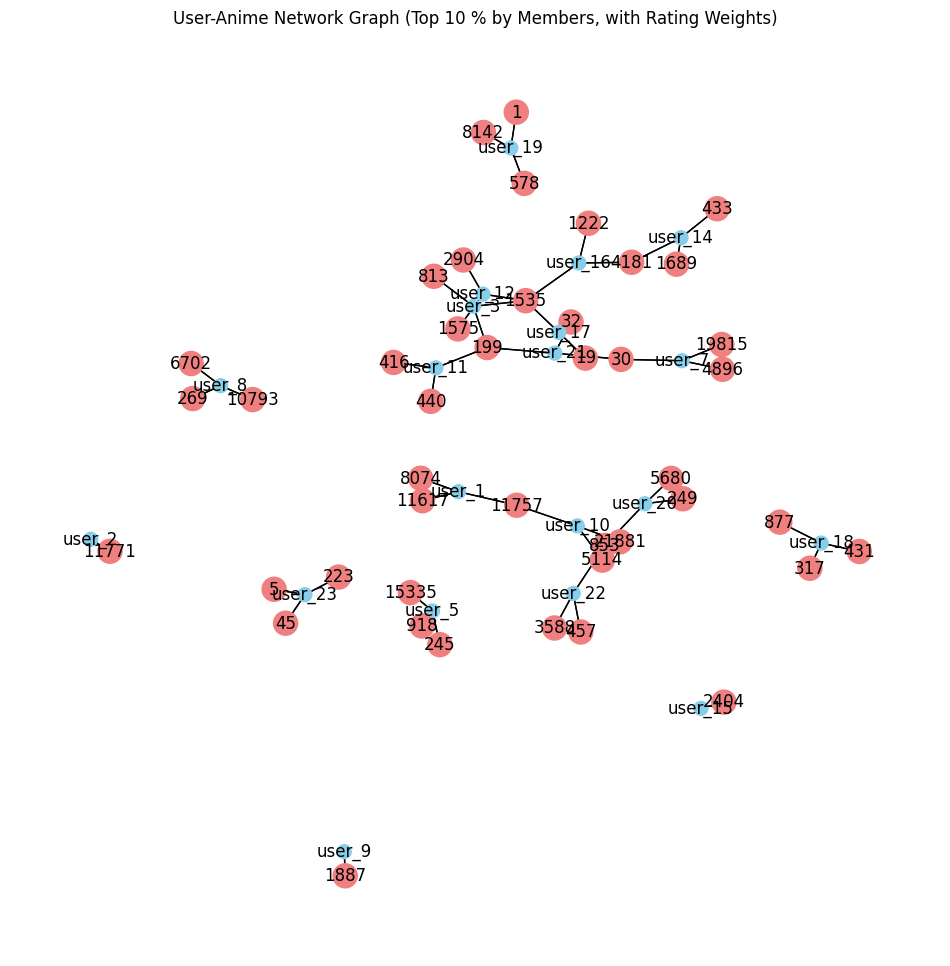

In [82]:
plt.figure(figsize = (12, 12))

pos = nx.spring_layout(G_20, k = 0.15, iterations=20, seed = 42)
nx.draw_networkx(G_20, node_color=color_map, node_size = size_list, 
                 pos = pos)
nx.draw_networkx_edges(G_20, pos = pos)


plt.title("User-Anime Network Graph (Top 10 % by Members, with Rating Weights)") 
plt.axis('off')   
plt.show()

## (+ 보너스 문제 1) 
지금부터는 가장 저평가, 고평가된 애니메이션 작품이 무엇일지 궁금해서 찾아보려고 합니다.

이에 앞서 어떻게 하면 분석하고자 하는 바를 수치화하여 비교할 수 있을지 다양한 아이디어를 제시해주세요.

> Naive Approach로 각 user_id 별로 rating score를 scaling 할 수 있다.
>
> user가 rating을 할 때 0~10 사이의 값을 매기지만 0~10의 기준이 자의적이기 때문에 평균, 분산 등이 모두 다를 수 있다.
>
> 예를 들어, user1은 항상 9 또는 10의 값을 매길 수 있고, user 2는 항상 1 또는 2의 값을 매길 수 있다.
>
> 즉, 각 user가 내린 평가에서 얼마나 높고, 낮은 평가를 내렸는가로 수치를 환산하여, 각 anime 별로 평균 rating score 를 계산하고 0~10 사이의 값으로 scaling 한다.
>
> 위 결과와 user_id 별로 scaling 하기 전의 anime 별 평균 rating score의 차이를 구함으로써 과대 평가 혹은 과소 평가 된 애니메이션 작품을 결정할 수 있다.




## 문제15. 
다양한 방법들이 있지만, 이번 분석에서는 얼마나 자주 시청하였는지, 즉 얼마나 애니메이션이 주변과의 연결성이 강한지를 지표로 사용하고자 합니다.

먼저 EigenvectorCentrality에 대해 조사하고 간단하게 설명해주세요.
 
(컴퓨팅 리소스의 한계로 유저별 상위 3개 작품만을 한정하지만, 본래 목적에 정확히 맞게 분석하려면 모든 시청한 작품을 포함시켜야합니다.)

> Node Centrality: Node가 그래프 내에서 얼마나 중요한지 나타내는 Measure로 Degree, Between, Eigen Centrality 등의 방식이 있다. 
> 
> Eigen Centrality: 이웃한 노드들의 중요도를 표현하는 Measure로 해당 노드 주위에 있는 노드가 중요한 노드면 해당 노드를 중요한 노드라고 판단한다. <br>
> 즉, 자기 자신이 아니라 이웃한 노드들의 중요도로 자신의 중요도가 결정된다. <br>
> 아래 식과 같이 v 노드의 중요도는 이웃 노드의 중요도 값을 모두 더하고 lambda로 나눈 값으로 정의된다. <br>
> 
> Lambda는 Adjacency Matrix와 중요도 vector x 사이의 eigenvector equation의 해 중에서 가장 큰 값을 사용한다.<br>

$$
x_v = \frac{1}{\lambda} \sum_{t \in M(v)} x_t = \frac{1}{\lambda} \sum_{t \in V} a_{v,t} x_t
$$
$$
Ax = \lambda x
$$

## (+ 보너스 문제 2) 
얼마나 주변과 잘 연결되어 있는지는 degree(단순 연결 개수)만으로도 측정할 수 있습니다.

Eigen Vector Centrality는 이러한 기존의 방식과 어떠한 차이점과 장점을 가질지 이번 분석과 연결하여 설명해주세요.

> 먼저, degree는 단순히 연결된 edge의 개수로 count 되기 때문에 직관적인 centrality 지표로 사용이 가능하다. <br> 
> 하지만, edge 개수로 count 되기 때문에 weight를 고려하지 못한다는 문제점이 발생하고 그래프가 가지는 potential 한 의미나 특징을 반영하기 어렵다. <br>
> 
> 시간복잡도: $O(V^2)$
> 
> 반면, Eigenvector Centrality는 어떤 노드가 중요한 노드에 연결되었는가를 판단하고, weight를 반영할 수 있다.<br>
> Eigenvector Centrality는 이웃 노드가 갖고 있는 특정한 값들에 기반을 두기 때문에 degree, betweeness, closeness 등의 지표를 Generalization 한 것이라 여길 수 있다. <br> 
> 본 분석에서는 user가 anime를 높게 혹은 낮게 평가했는가가 매우 중요한 요소라 할 수 있기 때문에 weight를 반영할 수 있는 Eigenvector Centrality를 사용하는 것이 보다 적절하다
> 
> 시간복잡도: $O(V^3)$

## 문제16. 
anime_nodes들에 대하여 eigen vector centrality를 구하고 standard_scaling을 진행한 후, 

우리가 구했던 rating의 평균과 표준편차에 맞게 변환하여주세요.
- (조건1) 점수가 10점 척도를 벗어날 수는 없습니다. np.clip() 함수를 이용하여 10점 척도로 제한하여주세요.
- (조건2) 명작들을 높게 평가한 유저들의 평가가 더욱 주요하게 반영되어야 합니다. 
- eigenvector_centrality를 구할 때 weight를 활용하도록 인자를 제공하여주세요.
- (HINT) networkx의 eigenvector_centrality를 이용하면 쉽게 계산할 수 있습니다. 또한,max_iter=1000 으로 설정하면 Iteration 관련 오류를 피할 수 있습니다.

In [118]:
# Get EigenVector Centrality of anime nodes
eigenvector_centrality = nx.eigenvector_centrality(G, max_iter = 1000,  weight='weight')
evc_anime = {node: eigenvector_centrality[node] for node in list(anime_nodes)}

# Scaling with StandardScaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
evc_anime_values = np.array(list(evc_anime.values())).reshape(-1, 1)
evc_anime_values = scaler.fit_transform(evc_anime_values)
evc_anime_values = evc_anime_values.flatten()


# transform the eigen vector entrality so the centrality can have mean mu and standard deviation sigma
evc_anime_values_  = evc_anime_values * sigma + mu

# Use np.clip to limit the value between 1 and 10
evc_anime_clipped = np.clip(evc_anime_values_, 1, 10)
evc_anime_dict = {node: value for node, value in zip(anime_nodes, evc_anime_clipped)}

print(f"Maximum value before clip {max(evc_anime_values_)}")
print(f"Maximum value after clip {max(evc_anime_clipped)}")

Maximum value before clip 17.44154743691141
Maximum value after clip 10.0


In [119]:
for idx, (k, v) in enumerate(evc_anime_dict.items()):
    print(f"{k}: {v}")
    if idx == 10:
        break

8074: 7.724372019656912
11617: 7.7032709836149795
11757: 8.089474088798875
11771: 7.594421064794444
199: 10.0
813: 8.258130418579425
1535: 10.0
245: 8.391029952509793
15335: 7.563525107476633
918: 7.890415221211364
30: 9.869218252300087


## 문제17. 
기존의 rating과 eigenvector_centrality의 차를 구한 후, 가장 고평가된 애니메이션과 저평가된 애니메이션의 작품명을 출력해주세요.

In [126]:
anime_rating_df = rating_df_selected.groupby("anime_id")["rating"].mean().sort_values(ascending = False)
anime_rating_df = pd.DataFrame(anime_rating_df)

anime_rating_df["evc"] = [evc_anime_dict[anime_id] for anime_id in anime_rating_df.index]
display(anime_rating_df.head())
display(anime_rating_df.isna().sum())

anime_rating_df["diff"] = anime_rating_df["rating"] - anime_rating_df["evc"]
anime_rating_df.head()

,rating,evc
anime_id,,
3702,10.0,7.584645
4901,10.0,7.560158
5671,10.0,7.557854
5630,10.0,7.571463
5530,10.0,7.586487


rating    0
evc       0
dtype: int64

,rating,evc,diff
anime_id,,,
3702,10.0,7.584645,2.415355
4901,10.0,7.560158,2.439842
5671,10.0,7.557854,2.442146
5630,10.0,7.571463,2.428537
5530,10.0,7.586487,2.413513


rating score와 Eigen Vector Centrality 차이의 min, max를 계산할 때 tie가 발생하여  해당하는 경우 모두 출력

In [125]:
min_diff = anime_rating_df["diff"].min()
max_diff = anime_rating_df["diff"].max()


under_rated_id = anime_rating_df[anime_rating_df["diff"] == min_diff].index
over_rated_id = anime_rating_df[anime_rating_df["diff"] == max_diff].index

under_rated_name = anime_df[anime_df["anime_id"].isin(under_rated_id)]["name"].unique()
over_rated_name = anime_df[anime_df["anime_id"].isin(over_rated_id)]["name"].unique()

print(f"Under rated anime: {under_rated_name}")
print(f"Over rated anime: {over_rated_name}")

Under rated anime: ['High School DxD BorN' 'Pupa']
Over rated anime: ['Kimi no Na wa.' 'JoJo no Kimyou na Bouken (TV)' 'Nichijou' 'SKET Dance'
 'Gyakkyou Burai Kaiji: Ultimate Survivor' 'Mimi wo Sumaseba'
 'Gyakkyou Burai Kaiji: Hakairoku-hen' 'Initial D First Stage'
 'Top wo Nerae! Gunbuster' 'Bokura wa Minna Kawaisou' 'Michiko to Hatchin'
 'Mitsudomoe' 'Inu x Boku SS' 'Sora no Otoshimono'
 'Kore wa Zombie Desu ka?' 'Kore wa Zombie Desu ka? OVA' 'Hiiro no Kakera']


# Chapter2 : Embedding&Clustering

> 이번 챕터에서는 구축한 그래프 데이터베이스를 바탕으로 유저의 클러스터링을 진행하고자 합니다.
> 
> 그러나, 시청 기록밖에 존재하지 않는 유저 데이터를 클러스터링 하는 것은 쉽지 않은 일입니다.
> 
> 어떻게 이런 제한적인 데이터를 효과적으로 클러스터링할 수 있을지 함께 알아보도록 합시다

## 문제1. 
이번 분석에서 사용할 패키지는 node2vec입니다. 해당 패키지를 설치해주세요

## 문제2. 
임베딩이 무엇인지 간략하게 설명해주세요.

> 텍스트, 이미지, 음성 등의 데이터를 수치형 벡터로 표현한 것으로 이미지 검색 엔진, 추천시스템, 챗봇 등에 활용된다.
>
> 임베딩을 real world data를 표현할 경우 데이터 도메인을 더 효과적으로 이해할 수 있는데, semantic relationship을 유지하면서 데이터의 표현방식을 단순화하기 때문이다.
>
> 그래프 임베딩의 경우 상호 연결된 노드에서 관련 정보를 추출하고 분류하여 네트워크 분석을 가능케 한다.

## 문제3.
nodeembedding은 그래프 구조에 맞게 노드를 임베딩하는 방법입니다.

우리가 사용할 node2vec 방법론을 바로 알아보기엔 무리가 있어, 준비된 코드를 사용하고자합니다.

embedder.py의 node_embedder를 외부 파일 import를 통해 불러와주세요.

In [26]:
from embedder import node_embedder 

## 문제4.
node_embedder는 networkx 그래프를 입력받아 nodeembedding 모델을 반환합니다.

우리의 그래프를 입력하고 해당 함수를 실행하여 모델을 model에 저장해주세요. 

(주의) 환경에 따라 5~15분의 시간이 소요될 수 있습니다

In [27]:
model = node_embedder(G)

Computing transition probabilities:   0%|          | 0/1394 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 2000/2000 [02:25<00:00, 13.73it/s]


## 문제5. 
임베딩 된 벡터를 바탕으로 Kmeans 클러스터링을 진행하고자 합니다.

Kmeans 클러스터링의 방법론과 다양한 하이퍼 파라미터들을 간략하게 설명해주세요


> 방법론: 임의의 지점을 선택해 군집 중심점을 설정하고, 해당 중심에 가장 가까운 포인트 들을 선택하는 군집화 기법 <br>
> 각 데이터는 가장 가까운 centroid에 클러스터링 되며, 중심점을 해당 클러스터의 평균 중심점으로 update한다. <br>
> 각 데이터는 다시 이동된 중심점 기준으로 가장 가까운 중심점에 소속되며 위 과정들을 반복하여 최종 중심점과 클러스터가 결정된다.
### Hyperparameter
- n_cluster : Cluster 개수
- n_init : 초기 중심위치 시도 횟수로 디폴트는 10. 10개의 중심위치 목록 중 가장 좋은 값을 선택한다.
- algorithm : 사용할 K-means algorithm, "elkan" 의 경우 삼각 부등식을 이용하여 well-defined clusters를 가진 데이터에서 좋은 성능을 보인다. 

## 문제6. 
model의 아래 사용법을 토대로 하여 임베딩 벡터를 기반으로 Kmeans 클러스터링을 진행해주세요.


<p>
-model 사용법

1.model.wv.vectors는 index에 순서에 맞게 nodeembedding된 벡터들이 저장되어있습니다.

2.model.wv.index_to_key는 index에 해당하는 node들을 Index 순서대로 출력하여줍니다.

Ex)

model.wv.vectors=array([[0.3,0.2,0.5],[1.0,0.8,0.7]])

model.wv.vectors=[‘13’,‘27’] 이라면 ‘13’ 노드의 임베딩은 [0.3,0.2,0.5], ‘27’ 노드의 임베딩은 [1.0,0.8,0.7]이됩니다.
</p>


- (조건1) Kmeans 클러스터링의 k=5,random_state=42로 설정해주세요.
- (조건2) 클러스터링에 anime node는 포함되어서는 안됩니다.

>1394개의 노드를 50-dimension에 임베딩

In [28]:
print(f"shape of embedding vectors: {model.wv.vectors.shape}")

shape of embedding vectors: (1394, 50)


In [29]:
# by index to key, get only user nodes
node_idx = [i for i in range(len(model.wv.index_to_key)) if "user_" in model.wv.index_to_key[i]]
print(node_idx[:10])

for i, idx in enumerate(node_idx):
    print(model.wv.index_to_key[idx], end = ', ')
    if i == 10:
        break

[69, 70, 81, 101, 102, 103, 105, 107, 116, 117]
user_448, user_798, user_992, user_988, user_398, user_769, user_93, user_174, user_720, user_383, user_973, 

In [30]:
node_embedding_vectors = model.wv.vectors[node_idx]
print(node_embedding_vectors.shape)

(931, 50)


In [31]:
from sklearn.cluster import KMeans

X = node_embedding_vectors
kmeans = KMeans(n_clusters=5, random_state=42).fit(X)
print(kmeans.labels_[:10])

c:\Users\82102\Anaconda3\envs\psat\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


[4 4 4 4 4 4 4 4 4 4]


In [32]:
unique, counts = np.unique(kmeans.labels_, return_counts=True)
print(np.asarray((unique, counts)).T)

[[  0 164]
 [  1 121]
 [  2 122]
 [  3 342]
 [  4 182]]


## 문제7.
생성된 클러스터를 조건에 맞게 아래와 같이 시각화해주세요.
- (조건1) 상위 50개의 user_id만을 활용해주세요. 자세한 방법은 챕터1 문제14의 조건1과 같습니다.
- (조건2) {anime node의 경우: "lightgray", 0:”red”,1: "blue",2: "green",3: "orange",4: "pink"}에 해당되도록 라벨에 해당하는 컬러를 적용하여 시각화해주세요.
- (조건3) spring_layout의 k=0.15,iteration=20,seed=42로 layout을 설정해주세요.

In [33]:
# Filter 50 users in graph by subgraph
user_nodes_50 = rating_df_selected["user_id_str"].unique()[:50]
print(user_nodes_50)

# Fitler anime node connected with top 50 users  
anime_nodes_connected_50 = set()
for user in user_nodes_50:
    anime_nodes_connected_50.update(G.neighbors(user))

subgraph_nodes = set(user_nodes_50).union(anime_nodes_connected_50)
G_50 = G.subgraph(subgraph_nodes)

print(G_50.edges())

['user_1' 'user_2' 'user_3' 'user_5' 'user_7' 'user_8' 'user_9' 'user_10'
 'user_11' 'user_12' 'user_14' 'user_15' 'user_16' 'user_17' 'user_18'
 'user_19' 'user_20' 'user_21' 'user_22' 'user_23' 'user_24' 'user_25'
 'user_26' 'user_27' 'user_28' 'user_29' 'user_30' 'user_31' 'user_32'
 'user_33' 'user_34' 'user_36' 'user_37' 'user_38' 'user_39' 'user_40'
 'user_41' 'user_42' 'user_43' 'user_44' 'user_45' 'user_46' 'user_47'
 'user_48' 'user_50' 'user_51' 'user_52' 'user_53' 'user_55' 'user_56']
[('user_42', 269), ('user_42', 855), ('user_42', 14075), ('user_50', 1), ('user_50', 19), ('user_50', 20), (1, 'user_19'), (1, 'user_32'), (1, 'user_43'), (1, 'user_46'), (1, 'user_51'), (3588, 'user_22'), (3588, 'user_30'), (5, 'user_23'), ('user_51', 19), ('user_51', 33), (6, 'user_32'), (6, 'user_55'), (523, 'user_47'), ('user_46', 164), ('user_46', 199), (15, 'user_33'), (1530, 'user_53'), (19, 'user_17'), (20, 'user_34'), (20, 'user_39'), (20, 'user_41'), (2581, 'user_31'), (22, 'user_55')

In [34]:
col_dict = {0:"red", 1: "blue", 2: "green", 3: "orange", 4: "pink"}

color_map = []
size_list = []
for node in G_50.nodes:
    if type(node) == str:
        cluster_id = kmeans.labels_[node_idx.index(model.wv.key_to_index[node])]
        color_map.append(col_dict[cluster_id])
        size_list.append(100)
    else:
        color_map.append("lightgray")
        size_list.append(300)

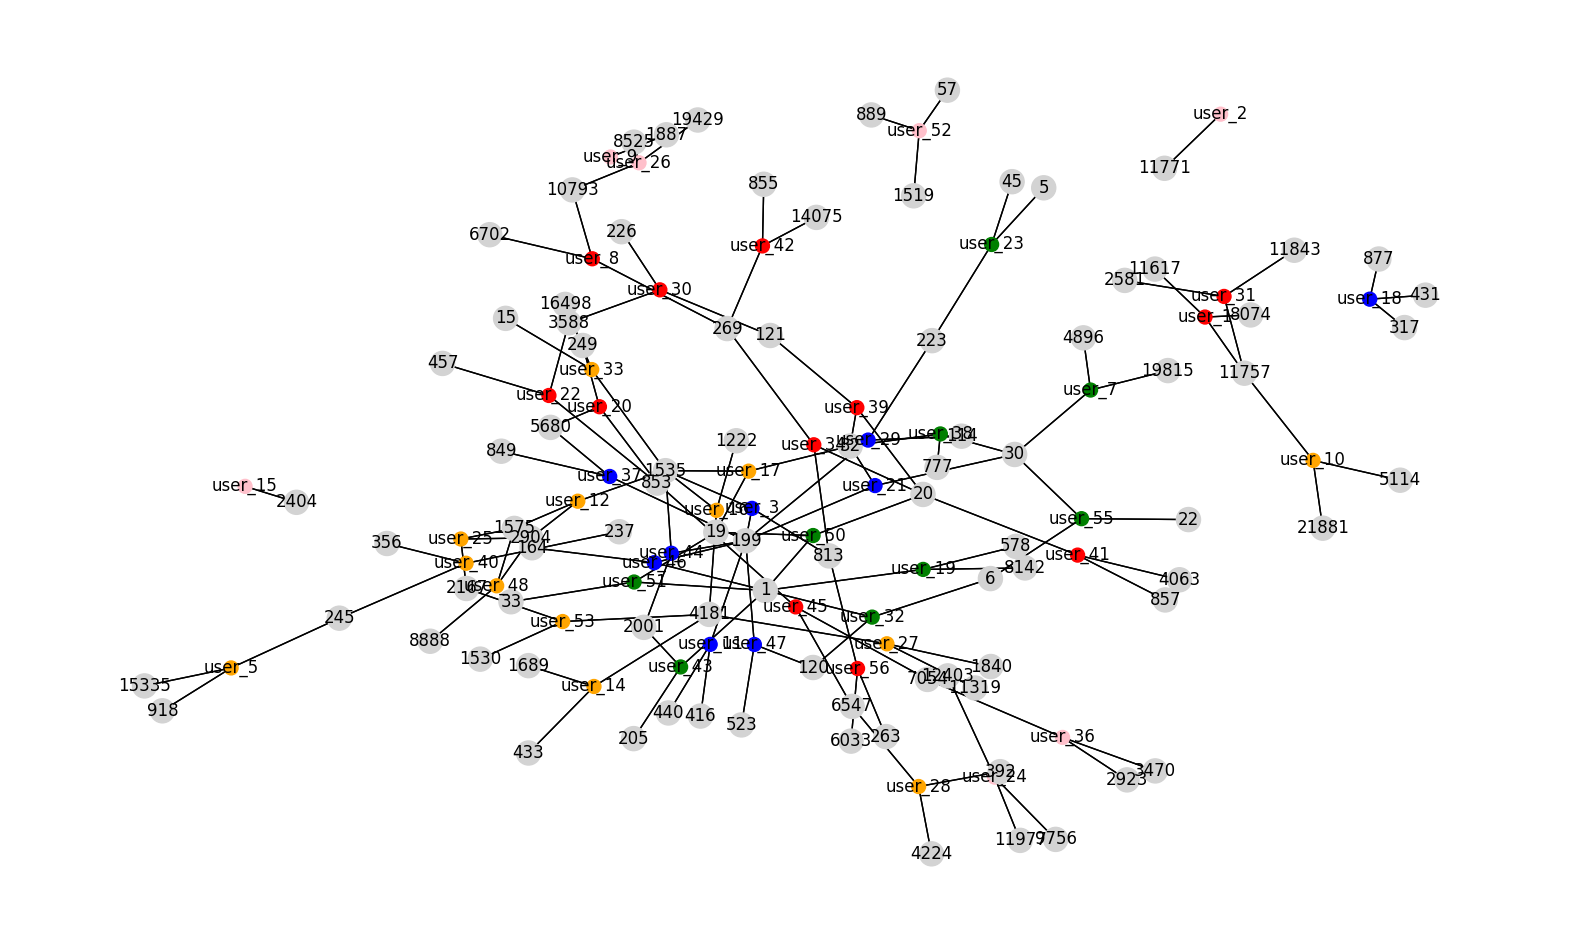

In [42]:
plt.figure(figsize = (20, 12))
pos = nx.spring_layout(G_50, k = 0.15, iterations=20, seed = 42)
nx.draw_networkx(G_50, node_color=color_map, node_size = size_list, 
                 pos=pos)
nx.draw_networkx_edges(G_50, pos = pos)

plt.axis('off')   
plt.show()

# Chapter3 : RecommendationSystem

유튜브, 넷플릭스 등을 보다보면 단순히 우리가 무언가를 시청한 것 만으로도 취향을 반영하여 새로운 영상을 추천해주고는 합니다.

또한, 요기요, 야놀자 등의 다양한 기업에서 이러한 추천시스템을 도입하고 있습니다.

이번 챕터에서는 가장 간단하게 구현할 수 있는 Link Prediction을 통해 사용자의 시청 기록만으로도 추천을 이어줄수 있는 시스템을 만들고자 합니다.

## 문제1. 
우리는 새로운 연결을 통해 사용자에게 시청하면 좋을 애니메이션을 추천해주고자 합니다. 

먼저 BipartiteGraph(이분그래프)에 대해 간략하게 설명해주세요.


<strong>BipartiteGraph(이분그래프)</strong>

모든 엣지의 연결이 한 집합의 노드에서 다른 집합의 노드로 연결되어 한 집합 내에서 연결이 존재하지 않는 그래프이다. 

특징: 
- 노드들이 두개의 disjoint한 집합으로 분할될 수 있음.
- cycle이 존재한다면 반드시 짝수의 길이를 가짐 (한 set 내에서 edge가 존재하지 않기 때문에 두개의 set을 번갈아 가면서 이동해야 cycle이 생김)
- Maximum Degree < Number of Nodes in Small Set

## 문제2. 
Link Prediction에 대해 간략하게 설명해주세요


#### Link Prediction

Link Prediction이란 두 node 사이의 잠재적인 관계(relationship or link)의 존재를 예측하는 문제로, social network 상에서 친구 관계의 연결 등을 예시로 들 수 있다.<br>
추천시스템에 Link Prediction을 적용할 수 있는데, Heuristic Method, Matrix Factorizaiton, GNN based Link Prediction 등의 방법이 존재한다. <br>

#### Local Heuristic Method: 
해당 노드의 로컬 이웃을 고려하여 두 노드 간의 유사도를 측정
- Common neighbors: 두 노드의 이웃의 Intersection의 개수
- Jaccard's Coefficient: Intersection of Neighbor / Union of Neighbor
- Global Heuristic Method: 로컬 이웃이 아닌 전체 네트워크를 고려하는 방법론으로 대표적으로 Katz Index, Random walk with Restart 기법이 존재한다.

#### Matrix Factorization: 
- Adjacency Matrix를 두개의 행렬로 분해하는 방법론으로 SVD, TSVD 등 존재

##### GNN based Link Prediction: 
- Neural Netowrk를 기반으로 한 모델로 GAE, VGAE 등 존재
- Graph Autoencoder: Encoder로 Graph의 특징을 추출하고 Latent Space에 Projection 하고, Decoder를 이용해 Latent Space의 Vector들로 Prediction 진행
- Variational Graph Autoencoder: 데이터의 분포(확률)에 대해서 학습함. <br> 
  GAE는 Embedding을 학습하는 것을 목표로 두지만, VGAE는 학습된 임베딩의 불확실성을 포착하기 위하여 정규 분포에 대하여 학습 진행. <br> 
  VGAE는 Latent Variable을 확률적으로 표현하는데, 평균과 분산으로 모델링하여 Embedding의 불확실성을 포착함.<br> 
  GCN을 Encoder로, Inner Product를 Decoder로 여겨, GCN에 VAE를 섞은 모델로 여길 수 있다.

## 문제3. 
이분 그래프 형태로 기존의 그래프를 변경할 예정입니다. 

이번에는 rating_df에서 user_id가 100미만 인 경우만을 불러와 ratind_df_100으로 저장하고,

상위 n개가 아닌 전체 범위를 모두 사용하여 B에 저장해주세요.

- (조건1) rating이 -1인 경우는 기존과 동일하게 제거합니다.
- (조건2) bipartite 0을 user,1을 item으로 지칭하고,“user_” 태그도 빠짐없이 달아주세요.
- (Hint) 그래프에 노드를 추가할 때,bipartite 인자를 통해 쉽게 이분 그래프로 나타낼 수 있습니다.

In [112]:
rating_df_100 =  rating_df[(rating_df['user_id'] < 100) & (rating_df['rating'] != -1)]
rating_df_100.shape

(6104, 3)

In [127]:
rating_df_100["user_id_str"] = rating_df_100["user_id"].astype(str)
rating_df_100["user_id_str"] = "user_" + rating_df_100["user_id_str"]
rating_df_100.head()

C:\Users\82102\AppData\Local\Temp\ipykernel_3396\4001247143.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rating_df_100["user_id_str"] = rating_df_100["user_id"].astype(str)
C:\Users\82102\AppData\Local\Temp\ipykernel_3396\4001247143.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rating_df_100["user_id_str"] = "user_" + rating_df_100["user_id_str"]


,user_id,anime_id,rating,user_id_str
47,1,8074,10,user_1
81,1,11617,10,user_1
83,1,11757,10,user_1
101,1,15451,10,user_1
153,2,11771,10,user_2


In [130]:
user_nodes_B = rating_df_100["user_id_str"].unique()
anime_nodes_B = rating_df_100["anime_id"].unique()

B = nx.Graph()

# Set user_node as set 0 and anime_node as set 1
B.add_nodes_from(user_nodes_B, bipartite = 0)
B.add_nodes_from(anime_nodes_B, bipartite = 1)
for index, row in rating_df_100.iterrows():
    B.add_edge(row['user_id_str'], row['anime_id'], weight=row['rating'])
print(B)

Graph with 1814 nodes and 6104 edges


## 문제4. 
이분그래프는 linkprediction에 다양한 제약이 존재합니다. 

따라서 우리는 katzindex를 통해 link prediction을 구현하고자 합니다.

katzindex에 대해 간략하게 설명해주세요.

> Katz Index는 두 노드 사이 모든 가능한 경로의 가중합을 계산하며 값이 클수록 link가 강하다고 간주한다.
>
> $\beta$ 로 경로의 길이에 따라 가중치를 낮게 부여한다.


$$
\text{KI}(u, v) = \sum_{l=1}^{\infty} \beta^l \left| \text{walks}^{\langle l \rangle}(u, v) \right| 
= \sum_{l=1}^{\infty} \beta^l \left( A^l \right)_{(u, v)} 
= \beta A_{(u, v)} + \beta^2 \left( A^2 \right)_{(u, v)} + \beta^3 \left( A^3 \right)_{(u, v)} + \dots
$$

$$
\text{KI}(u, v): \text{Katz Index} 
$$

$$
\beta: \text{attenuation factor, 경로의 길이에 따라 Katz 중심성에 가중치를 부여.} 
$$

$$
\text{walks}^{\langle l \rangle}(u, v): \text{노드 } u \text{와 } v \text{ 사이의 길이 } l \text{인 경로 수}
$$

$$
A: \text{그래프의 인접 행렬 (adjacency matrix)로, } A_{ij} \text{는 노드 } i \text{와 } j \text{ 사이의 엣지 존재 여부}
$$

$$
(A^l)_{(u, v)}: \text{노드 } u \text{와 } v \text{ 사이의 길이 } l \text{인 경로에 해당하는 인접 행렬의 값}

$$

## 문제5. 
각 노드간의 katzindex를 모두 구한 후, 유저가 시청하지 않은 anime에 대하여 user-anime간 katzindex가 가장 높은 항목과 index 값을 출력해주세요.
- (조건) katzindex를 구할 때, 파라미터를 alpha=0.005, beta=1.0, weight= ‘weight’로 설정해주세요.


<strong>katz_centrality_numpy(G, alpha=0.1, beta=1.0, normalized=True, weight=None)</strong>

weight : None or string, optional 

If None, all edge weights are considered equal. Otherwise holds the name of the edge attribute used as weight. 

In this measure the weight is interpreted as the connection strength.


In [ ]:
# get karz index
# weight: rating score
katz_B = nx.katz_centrality_numpy(B, alpha = 0.005, beta = 1, weight = "weight")

존재하지 않는 User Anime Pair로 필터링

In [204]:
import itertools

non_existing_edges = [(u, v) for u, v in itertools.product(user_nodes_B, anime_nodes_B) if not B.has_edge(u, v)]
predicted_links_kz = []

for u, v in non_existing_edges:
    combined_katz_score = katz_B[u] * katz_B[v]
    predicted_links_kz.append((u, v, combined_katz_score))

predicted_links_kz.sort(key=lambda x: x[2], reverse=True)

In [205]:
for u, v, score in predicted_links_kz[:10]:  
    v_name = anime_df[anime_df["anime_id"] == v].iloc[0]["name"]
    
    print(f"User: {u}, Anime: {v_name}, Katz Index: {score}")


User: user_46, Anime: Angel Beats!, Katz Index: 0.026982789736048087
User: user_46, Anime: Mirai Nikki (TV), Katz Index: 0.019458310042608933
User: user_38, Anime: Sen to Chihiro no Kamikakushi, Katz Index: 0.0175111485985041
User: user_46, Anime: Another, Katz Index: 0.017047430266561695
User: user_38, Anime: Steins;Gate, Katz Index: 0.016911989798801923
User: user_38, Anime: Ano Hi Mita Hana no Namae wo Bokutachi wa Mada Shiranai., Katz Index: 0.016736108393329126
User: user_21, Anime: Sword Art Online, Katz Index: 0.016310108434987907
User: user_46, Anime: Tengen Toppa Gurren Lagann, Katz Index: 0.016068436674163803
User: user_46, Anime: Fate/Zero, Katz Index: 0.015663235860333323
User: user_43, Anime: Death Note, Katz Index: 0.01561621234063472


## (+ 보너스 문제 3)
그래프 데이터에서 shortest_path가 무엇인지 설명하고, 해당 지수를 활용한 방식으로 linkprediction을 진행해주세요.

<strong>Shrotest Path</strong>
<p>
Shortest Path란 그래프 이론과 그래프 데이터베이스에서 기본적인 topological feature로 

recommender system에서 사용될 경우 cosine similarity와 비교했을 때 비해 shorteat path는 사건의 발생 순서를 imply 할 수 있다는 이점을 가진다. 

예를 들어, user1이 anime 1을 시청하고 이후 anime 101을 시청하는 경로로 이동하는 것과 같이 ordered sequence의 imply가 가능하다.
</p>

<p>
Edge에 weight가 존재하는 경우 주의해야하는데 weight가 distance 인 경우 distance의 합을 최소로 하는 shortest path를 찾을 수 있으나 

weight가 선호도로 설정될 경우 선호도의 합이 가장 낮은 경로로 shortest path를 찾게 된다. 즉, 분석 목적에 맞지 않는 결과를 가져온다.

때문에 선호도의 경우 역수를 취하는 등의 전처리를 통하여 shortest path를 찾을 수 있다.
</p>

<br>

### NetworkX.all_pairs_dijkstra_path_length

Parameters:

cutoff : integer or float, optional

<strong>Length (sum of edge weights) </strong>at which the search is stopped. If cutoff is provided, only return paths with summed weight <= cutoff.


Notes

Edge weight attributes must be numerical. <strong>Distances are calculated as sums of weighted edges traversed.</strong>

The dictionary returned only has keys for reachable node pairs.

In [ ]:
def inverse_weight(d):
    return 1 / d['weight']

shortest_paths = dict(nx.all_pairs_dijkstra_path_length(B, weight=inverse_weight))

In [209]:
# Filter out non-existing edges in Original Graph
non_existing_edges = [(u, v) for u, v in itertools.product(user_nodes_B, anime_nodes_B) if not B.has_edge(u, v)]

predicted_links_sp = {}
for u, v in non_existing_edges:
    if (u in shortest_paths) and (v in shortest_paths[u]):
        if u not in predicted_links_sp:
            predicted_links_sp[u] = [[v, round(shortest_paths[u][v], 3)]]
        else:
            predicted_links_sp[u].append([v, round(shortest_paths[u][v], 3)])


High School DxD가 자주 높은 Link Prediction (낮은 shortet_path값) 을 보여준다. 

일본의 후지미 판타지아 문고에서 출판되고 있는 라이트 노벨이라고 한다

Fullmetal Alchemist(강철의 연금술사)는 글쓴이의 최애 애니이다.

In [210]:
for k ,v in predicted_links_sp.items():
    predicted_links_sp[k] = sorted(v, key = lambda x: x[1])

for idx, (k, v) in enumerate(predicted_links_sp.items()):
    if idx == 10:
        break
    v_name = anime_df[anime_df["anime_id"] == v[0][0]].iloc[0]["name"]
    print(f"User: {k},  Anime: {v_name}, Shortest Path: {v[0][1]}")


User: user_1,  Anime: Naruto, Shortest Path: 0.3
User: user_2,  Anime: Sen to Chihiro no Kamikakushi, Shortest Path: 0.3
User: user_3,  Anime: High School DxD, Shortest Path: 0.3
User: user_5,  Anime: Fullmetal Alchemist: Brotherhood, Shortest Path: 0.3
User: user_7,  Anime: Kuroko no Basket, Shortest Path: 0.3
User: user_8,  Anime: High School DxD, Shortest Path: 0.3
User: user_9,  Anime: Sword Art Online, Shortest Path: 0.325
User: user_10,  Anime: High School DxD, Shortest Path: 0.3
User: user_11,  Anime: High School DxD, Shortest Path: 0.3
User: user_12,  Anime: High School DxD, Shortest Path: 0.3


## (+ 보너스 문제 4)
preferential attachment가 무엇인지 가정을 포함하여 간략하게 설명한 후, preferential attachment를 활용하여 link prediction을 진행해주세요.
- (Hint)nx.preferential_attachment()을 활용하면 쉽게 preferential attachment를 통한 link prediction 을 수행할 수 있습니다.

### Preferential Attachment
빈익빈 부익부와 유사한 아이디어를 갖고 있다.

새로운 node는 이미 edge가 많은 node와 연결될 가능성이 높다는 아이디어에 착안되었는데 새로운 node가 기존 노드 i에 연결될 확률은 아래와 같이 정의되며 <br>
$k_i$는 i node의 degree로 새로운 node가 기존 노드 i에 연결될 확률은 전체 degree 중 i degree의 비율로 계산된다.


$$
\Pi(k_i) = \frac{k_i}{\sum_j k_j}
$$


### Preferential Attachment Similarity
Preferential Attachment Similarity는 단순히 두 노드의 Degree를 곱한 값으로 정의되는데, 

그래프 내의 모든 노드 간 유사도를 계산할 때 nC2 만큼의 연산이 발생한다. 

$$S(u, v) = k_u \cdot k_v.$$




In [186]:
# Calculate preferential attachment
preferential_attachment = list(nx.preferential_attachment(B))

pa_dict = {}
for u, v, p in preferential_attachment:
    if u not in pa_dict:
        pa_dict[u] = {v: p}
    else:
        pa_dict[u][v] = p

In [187]:
non_existing_edges = [(u, v) for u, v in itertools.product(user_nodes_B, anime_nodes_B) if not B.has_edge(u, v)]

links_predicted_pa = {}
for u, v in non_existing_edges:
    if (u in pa_dict) and (v in pa_dict[u]):
        if u not in links_predicted_pa:
            links_predicted_pa[u] = [[v, round(pa_dict[u][v], 3)]]
        else:
            links_predicted_pa[u].append([v, round(pa_dict[u][v], 3)])

분석 결과 Angel Beats라는 만화 영화를 많이 추천하는 것을 확인할 수 있다. 

<strong>해당 만화 영화의 줄거리 : </strong> 

주인공 오토나시 유즈루는 기억을 잃은 채, 어느 학교에 떨어진다. 이곳은 생전의 미련을 풀지 못한 채 죽은 학생들이 모이는 사후세계란 곳으로, 성실하게 학교 생활을 수행하면 성불한다. 

오토나시는 이곳에서 유리를 중심으로 한 사후세계 전선(SSS)의 학생들을 만나게 된다. 이들은 수업을 거부하고 사후세계를 빼앗기 위해, 학생들을 성불시키려 하고 있는 학생회장인 천사와 

싸우고 있었다. 오토나시는 얼떨결에 유리의 권유를 받아 SSS에 가입하고, SSS의 멤버들과 어울리며 개개인의 사정을 알게 되는 한편 천사와 사후세계의 비밀도 알아가게 되는데....

In [189]:
for k ,v in links_predicted_pa.items():
    links_predicted_pa[k] = sorted(v, key = lambda x: x[1], reverse = True)

for idx, (k, v) in enumerate(links_predicted_pa.items()):
    if idx == 10:
        break
    v_name = anime_df[anime_df["anime_id"] == v[0][0]].iloc[0]["name"]
    print(f"User: {k},  Anime: {v_name}, PA SIMILARITY: {v[0][1]}")

User: user_1,  Anime: Angel Beats!, Shortest Path: 148
User: user_2,  Anime: Sword Art Online, Shortest Path: 46
User: user_3,  Anime: Hataraku Maou-sama!, Shortest Path: 1656
User: user_5,  Anime: Fullmetal Alchemist: Brotherhood, Shortest Path: 14688
User: user_7,  Anime: Highschool of the Dead, Shortest Path: 8232
User: user_8,  Anime: Highschool of the Dead, Shortest Path: 288
User: user_9,  Anime: Angel Beats!, Shortest Path: 37
User: user_10,  Anime: Highschool of the Dead, Shortest Path: 72
User: user_11,  Anime: Angel Beats!, Shortest Path: 4070
User: user_12,  Anime: Angel Beats!, Shortest Path: 814
